Download checkpoints

In [ ]:
import os
import gdown

url = "https://drive.google.com/drive/folders/14_82FwfaOxERGILfYU3zDlQrvpZR7NEc?usp=drive_link"
output_dir = "checkpoints"

if os.path.exists(output_dir) and len(os.listdir(output_dir)) > 0:
    print(f"{output_dir} already exists and is not empty, skip downloading.")
else:
    gdown.download_folder(
        url=url,
        output=output_dir,
        quiet=False,
        use_cookies=False
    )

The hypercomplex data is split into real and imaginary parts to obtain A3DK08_r.mat and A3DK08_i.mat data-1

In [1]:
import nmrglue as ng
#import mat4py as mt
import pylab
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

data_types = ['A3DK08'] # 'A3DK08','PSRP','mousethia','Ecolinird','Ykvr','Altg','Yorp'

for data_type in data_types:
    dic,data = ng.pipe.read(f'./data/{data_type}_label.ft1')
    # dic,data = ng.pipe.read(f"F:/NMRPipe/ReadNMRData/az_HNCA_high_res/az_HNCA_high_res.fid/azurin_hyper.ft1")
    # data = np.transpose(data,axes=(2, 0, 1))
    udic = ng.varian.guess_udic(dic,data)
    print(udic)
    #
    print(data.ndim)
    print(data.shape)
    print(data.dtype)


    sio.savemat(f'./data/{data_type}_label.mat',{'data':data}, format='5')



{'ndim': 3, 0: {'sw': 999.99, 'complex': True, 'obs': 999.99, 'car': 999.99, 'size': 80, 'label': 'X', 'encoding': 'states', 'time': True, 'freq': False}, 1: {'sw': 999.99, 'complex': True, 'obs': 999.99, 'car': 999.99, 'size': 128, 'label': 'Y', 'encoding': 'states', 'time': True, 'freq': False}, 2: {'sw': 999.99, 'complex': True, 'obs': 999.99, 'car': 999.99, 'size': 512, 'label': 'Z', 'encoding': 'direct', 'time': True, 'freq': False}}
3
(80, 128, 512)
float32


The hypercomplex data is split into real and imaginary parts to obtain A3DK08_r.mat and A3DK08_i.mat data-2

[ 0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46
 48 50 52 54 56 58 60 62 64 66 68 70 72 74 76 78]


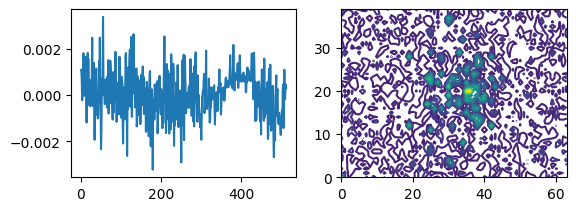

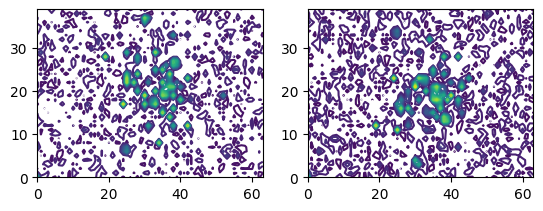

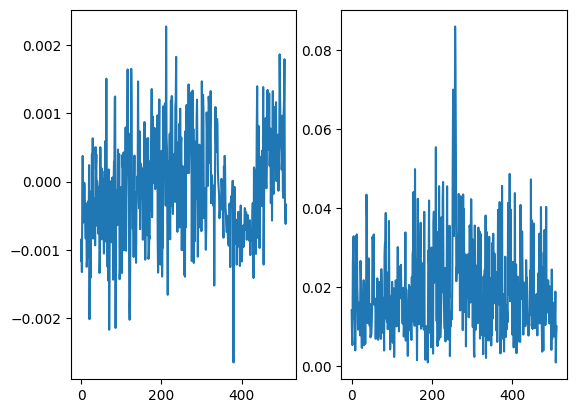

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import nmrglue as ng
import os
import scipy.io as sio

data_types = ['A3DK08'] # 'A3DK08','PSRP','mousethia','Ecolinird','Ykvr','Altg','Yorp'

for data_type in data_types:
    data = sio.loadmat(f'./data/{data_type}_label.mat')['data']
    N1 = data.shape[0]
    N2 = data.shape[1]
    N3 = data.shape[2]
    # print(N1,N2,N3)

    r1 = np.arange(0, N1, 2)
    i1 = np.arange(1, N1, 2)
    r2 = np.arange(0, N2, 2)
    i2 = np.arange(1, N2, 2)
    print(r1)

    Rr = data[np.ix_(r1, r2)]
    Ri = data[np.ix_(r1, i2)]
    Ir = data[np.ix_(i1, r2)]
    Ii = data[np.ix_(i1, i2)]

    fid1 = Rr + 1j*Ri #Rc cos(w1*t1)*exp(1i*w2*t2)
    fid2 = Ir + 1j*Ii #Ic sin(w1*t1)*exp(1i*w2*t2)

    fid_r1 = fid1+1j*fid2 # echo                                  
    fid_r2 = fid1-1j*fid2 # anti-echo 预处理成与训练数据一致的类型   


    # sio.savemat(f'A3DK08.mat',{'Xr':fid1,'Xi':fid2})
    sio.savemat(f'./data/{data_type}_r.mat', {'data': fid_r1})
    sio.savemat(f'./data/{data_type}_i.mat', {'data': fid_r2})
    # sio.savemat(f'A3DK08.mat',{'Xr':fid1,'Xi':fid2})
    # sio.savemat(f'{data_type}_hyper.mat',{'Xr':fid_r1,'Xi':fid_r2})


    spec1 = np.zeros((N1//2,N2//2,N3), dtype=complex)
    spec2 = np.zeros((N1//2,N2//2,N3), dtype=complex)
    for i in range(N3):
        spec1[:,:,i] = np.fft.fft2(fid1[:,:,i])
        spec2[:,:,i] = np.fft.fft2(fid2[:,:,i])
    plt.figure()
    plt.subplot(221)
    plt.plot(np.squeeze(np.real(fid_r1[1,1,:])))
    plt.subplot(222)
    plt.contour(np.max(np.abs(spec2),axis=2),cmap='viridis',levels=21)
    plt.show()

    for i in range(N3):
        spec1[:,:,i] = np.fft.fft2(fid_r1[:,:,i])
        spec2[:,:,i] = np.fft.fft2(fid_r2[:,:,i])
    plt.figure()
    plt.subplot(221)
    plt.contour(np.max(np.abs(spec1),axis=2),cmap='viridis',levels=21)
    plt.subplot(222)
    plt.contour(np.max(np.abs(spec2),axis=2),cmap='viridis',levels=21)
    plt.show()

    plt.figure()
    plt.subplot(1,2,1)
    plt.plot(np.squeeze(np.real(fid1[1,0,:])))
    plt.subplot(1,2,2)
    plt.plot(np.squeeze(np.abs(np.fft.fftshift(np.fft.fft(fid1[1,0,:].squeeze())))))
    plt.show()

Slice the A3DK08_r.mat data along the direct dimension.

In [3]:
import os
import numpy as np
from scipy.io import loadmat, savemat
from scipy.fftpack import fft, fftshift

data = loadmat('./data/A3DK08_r.mat')
spec1 = data['data']

spec1 = fft(spec1, axis=0)
spec1 = fft(spec1, axis=1)
spec1 = fftshift(spec1, axes=(0, 1))

third_dim_size = spec1.shape[2]

folder_name = 'data/data64/A3DK08_r_slices'
os.makedirs(folder_name, exist_ok=True)

for i in range(third_dim_size):
    spec = spec1[:, :, i]

    filename = f'label_spec{i+1}.mat'
    filepath = os.path.join(folder_name, filename)

    savemat(filepath, {'spec': spec})


Slice the A3DK08_i.mat data along the direct dimension.

In [4]:
import os
import numpy as np
from scipy.io import loadmat, savemat
from scipy.fftpack import fft, fftshift

data = loadmat('./data/A3DK08_i.mat')
spec1 = data['data']

spec1 = fft(spec1, axis=0)
spec1 = fft(spec1, axis=1)
spec1 = fftshift(spec1, axes=(0, 1))

third_dim_size = spec1.shape[2]

folder_name = 'data/data64/A3DK08_i_slices'
os.makedirs(folder_name, exist_ok=True)

for i in range(third_dim_size):
    spec = spec1[:, :, i]

    filename = f'label_spec{i+1}.mat'
    filepath = os.path.join(folder_name, filename)

    savemat(filepath, {'spec': spec})


reconstruct A3DK08_r

In [ ]:
import argparse
import os
import random
import traceback

import matplotlib.pyplot as plt
import numpy as np
import scipy.io as scio
import torch

import core.logger as Logger
import core.metrics as Metrics
import model.model64 as Model

parser = argparse.ArgumentParser()
parser.add_argument('-c', '--config', type=str, default='config/sr_sr3_256_256_val64_r.json',
                    help='JSON file for configuration')
parser.add_argument('-p', '--phase', type=str, choices=['train', 'val'],
                    help='Run either train(training) or val(generation)', default='val')
parser.add_argument('-gpu', '--gpu_ids', type=str, default=None)
parser.add_argument('-debug', '-d', action='store_true')
parser.add_argument('-enable_wandb', action='store_true')
parser.add_argument('-log_wandb_ckpt', action='store_true')
parser.add_argument('-log_eval', action='store_true')
args = parser.parse_args(args=[])
opt = Logger.parse(args)
opt = Logger.dict_to_nonedict(opt)

data = 'A3DK08_r'
base_path = f"./data/data64/{data}_slices/label_spec"

BLOCK_SIZE = 64
sequence_BATCH_SIZE = 64
MASK_POOL_SIZE = 1000

torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = True


def pad_data(data, block_size):
    height, width = data.shape
    pad_height = (block_size - height % block_size) % block_size
    pad_width = (block_size - width % block_size) % block_size
    padded_data = np.pad(data, ((0, pad_height), (0, pad_width)), mode='constant', constant_values=0)
    return padded_data, pad_height, pad_width


def block_data(data, block_size):
    padded_data, pad_height, pad_width = pad_data(data, block_size)
    height, width = padded_data.shape
    num_blocks_vertical = height // block_size
    num_blocks_horizontal = width // block_size
    blocks = np.empty((num_blocks_vertical * num_blocks_horizontal, block_size, block_size), dtype=padded_data.dtype)
    idx = 0
    for i in range(num_blocks_vertical):
        for j in range(num_blocks_horizontal):
            block = padded_data[i * block_size:(i + 1) * block_size, j * block_size:(j + 1) * block_size]
            blocks[idx] = block
            idx += 1
    return blocks, padded_data.shape, pad_height, pad_width


def reconstruct_data(blocks, pad_shape, pad_height, pad_width):
    height, width = pad_shape
    _, block_height, block_width = blocks.shape
    num_blocks_vertical = height // block_height
    num_blocks_horizontal = width // block_width
    reconstructed_data = np.empty((height, width), dtype=blocks.dtype)
    idx = 0
    for i in range(num_blocks_vertical):
        for j in range(num_blocks_horizontal):
            block = blocks[idx]
            reconstructed_data[i * block_height:(i + 1) * block_height, j * block_width:(j + 1) * block_width] = block
            idx += 1
    final_data = reconstructed_data[
        :height - (pad_height if pad_height != 0 else 0),
        :width - (pad_width if pad_width != 0 else 0)
    ]
    return final_data


def prepare_sequence_sample(sequence):

    dynamic_real_data_path = f"{base_path}{sequence}"
    data_path = f"{dynamic_real_data_path}.mat"
    if not os.path.isfile(data_path):
        return None

    ori_spec = scio.loadmat(data_path)['spec']
    n1 = ori_spec.shape[0]
    n2 = ori_spec.shape[1]

    threshold = 0.01
    amp_max = np.max(np.abs(ori_spec), axis=1, keepdims=True)
    mask = np.abs(ori_spec) < amp_max * threshold
    ori_spec[mask] = 0

    phase_input, pad_shape, pad_height, pad_width = block_data(ori_spec, BLOCK_SIZE)
    xx = np.fft.ifft2(ori_spec)

    random_integer = random.randint(1, MASK_POOL_SIZE)
    mask_path = f"./data/data64/0.08_2D_mask-{n1}-{n2}/Mask_{random_integer}.mat"
    if not os.path.isfile(mask_path):
        return None

    sampled_mask = scio.loadmat(mask_path)['Mask']

    nus_fid = np.multiply(sampled_mask, xx)
    noise_input = np.fft.fft2(nus_fid)
    nus_fid, _, _, _ = block_data(nus_fid, BLOCK_SIZE)
    noise_input, _, _, _ = block_data(noise_input, BLOCK_SIZE)

    gt_label = np.fft.fft2(xx)
    gt_label, _, _, _ = block_data(gt_label, BLOCK_SIZE)
    block_num = phase_input.shape[0]

    max_amp = np.max(np.abs(noise_input))
    if max_amp == 0:
        return None

    nus_fid_tensor = torch.complex(
        torch.from_numpy(nus_fid.real).float(),
        torch.from_numpy(nus_fid.imag).float()
    ) / (max_amp * 11)
    noise_input_tensor = torch.complex(
        torch.from_numpy(noise_input.real).float(),
        torch.from_numpy(noise_input.imag).float()
    ) / max_amp
    gt_label_tensor = torch.complex(
        torch.from_numpy(gt_label.real).float(),
        torch.from_numpy(gt_label.imag).float()
    ) / (max_amp * 12.5)

    lr = nus_fid_tensor.unsqueeze(1)
    sr = torch.cat((noise_input_tensor.real.unsqueeze(1), noise_input_tensor.imag.unsqueeze(1)), dim=1)
    hr = torch.cat((gt_label_tensor.real.unsqueeze(1), gt_label_tensor.imag.unsqueeze(1)), dim=1)

    return {
        'sequence': int(sequence),
        'LR': lr,
        'SR': sr,
        'HR': hr,
        'meta': {
            'pad_shape': (int(pad_shape[0]), int(pad_shape[1])),
            'pad_height': int(pad_height),
            'pad_width': int(pad_width),
            'block_num': int(block_num),
            'real_data_path': dynamic_real_data_path
        }
    }


def run_batch_inference(diffusion, samples, result_path):
    if not samples:
        return

    lr_list = []
    sr_list = []
    hr_list = []
    batch_meta = []

    cursor = 0
    for sample in samples:
        block_num = sample['meta']['block_num']
        start = cursor
        end = cursor + block_num

        lr_list.append(sample['LR'])
        sr_list.append(sample['SR'])
        hr_list.append(sample['HR'])

        batch_meta.append({
            'sequence': sample['sequence'],
            'start': int(start),
            'end': int(end),
            'pad_shape': [sample['meta']['pad_shape'][0], sample['meta']['pad_shape'][1]],
            'pad_height': sample['meta']['pad_height'],
            'pad_width': sample['meta']['pad_width'],
            'real_data_path': sample['meta']['real_data_path']
        })
        cursor = end

    print(f"[Batch] sequence={[meta['sequence'] for meta in batch_meta]}, total_blocks={cursor}")

    val_data = {
        'LR': torch.cat(lr_list, dim=0),
        'HR': torch.cat(hr_list, dim=0),
        'SR': torch.cat(sr_list, dim=0)
    }

    opt['datasets']['test']['batch_meta'] = batch_meta
    opt['datasets']['test']['real_data_path'] = samples[0]['meta']['real_data_path']
    try:
        val_data = diffusion.set_device(val_data)
        diffusion.feed_data(val_data)
        diffusion.test(continous=False)
        visuals = diffusion.get_current_visuals()

        total_blocks = cursor
        sr_final = visuals['SR'][-total_blocks:]

        for meta in batch_meta:
            start = meta['start']
            end = meta['end']
            sequence = meta['sequence']
            pad_shape = tuple(meta['pad_shape'])
            pad_height = meta['pad_height']
            pad_width = meta['pad_width']

            fake_img = reconstruct_data(
                torch.complex(visuals['INF'][start:end, 0], visuals['INF'][start:end, 1]).cpu().numpy(),
                pad_shape, pad_height, pad_width
            )
            sr_img = reconstruct_data(
                torch.complex(sr_final[start:end, 0], sr_final[start:end, 1]).cpu().numpy(),
                pad_shape, pad_height, pad_width
            )
            sr_spec = reconstruct_data(
                torch.complex(visuals['SR_Spec'][start:end, 0], visuals['SR_Spec'][start:end, 1]).cpu().numpy(),
                pad_shape, pad_height, pad_width
            )
            hr_img = reconstruct_data(
                torch.complex(visuals['HR'][start:end, 0], visuals['HR'][start:end, 1]).cpu().numpy(),
                pad_shape, pad_height, pad_width
            )
            Metrics.save_contour2D(
                nus_spec=fake_img,
                recon_spec=sr_img,
                label_spec=hr_img,
                sr_spec=sr_spec,
                sequence=sequence,
                save_path='{}/{}_{}_hr.png'.format(result_path, 200, sequence),
                dataset_name=data
            )
            plt.close('all')
    finally:
        opt['datasets']['test']['batch_meta'] = None


def chunk_list(values, chunk_size):
    for start in range(0, len(values), chunk_size):
        yield values[start:start + chunk_size]


if __name__ == '__main__':
    diffusion = Model.create_model(opt)
    diffusion.set_new_noise_schedule(opt['model']['beta_schedule']['val'], schedule_phase='val')

    result_path = '{}/{}'.format(opt['path']['results'], 100)
    os.makedirs(result_path, exist_ok=True)

    sequence_all = list(range(0, 522))

    for sequence_batch in chunk_list(sequence_all, sequence_BATCH_SIZE):
        prepared_samples = []
        for sequence in sequence_batch:
            try:
                sample = prepare_sequence_sample(sequence)
                if sample is not None:
                    prepared_samples.append(sample)
            except Exception as e:
                print(f"{e}")

        if not prepared_samples:
            continue

        try:
            run_batch_inference(diffusion, prepared_samples, result_path)
        except Exception as e:
            print(f"{e}")
            traceback.print_exc()

export CUDA_VISIBLE_DEVICES=0
[Batch] sequence=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63], total_blocks=63


sampling loop time step: 100%|██████████| 2000/2000 [01:20<00:00, 24.74it/s] 
/mnt/DATA1/guanxun/code/NUS_Diffusion_git/model/model64/model64.py:109: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at  /opt/conda/conda-bld/pytorch_1656352660876/work/aten/src/ATen/native/Copy.cpp:250.)
  out_dict['LR'] = self.data['LR'].detach().float().cpu()


[Batch] sequence=[64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127], total_blocks=64


sampling loop time step: 100%|██████████| 2000/2000 [01:19<00:00, 25.11it/s]  


[Batch] sequence=[128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191], total_blocks=64


...

sampling loop time step: 100%|██████████| 2000/2000 [01:18<00:00, 25.53it/s]  


[Batch] sequence=[448, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511], total_blocks=64


sampling loop time step: 100%|██████████| 2000/2000 [01:18<00:00, 25.41it/s]  


[Batch] sequence=[512], total_blocks=1


sampling loop time step: 100%|██████████| 2000/2000 [00:11<00:00, 169.94it/s] 


reconstruct A3DK08_i

In [ ]:
import argparse
import os
import random
import traceback

import matplotlib.pyplot as plt
import numpy as np
import scipy.io as scio
import torch

import core.logger as Logger
import core.metrics as Metrics
import model.model64 as Model

parser = argparse.ArgumentParser()
parser.add_argument('-c', '--config', type=str, default='config/sr_sr3_256_256_val64_i.json',
                    help='JSON file for configuration')
parser.add_argument('-p', '--phase', type=str, choices=['train', 'val'],
                    help='Run either train(training) or val(generation)', default='val')
parser.add_argument('-gpu', '--gpu_ids', type=str, default=None)
parser.add_argument('-debug', '-d', action='store_true')
parser.add_argument('-enable_wandb', action='store_true')
parser.add_argument('-log_wandb_ckpt', action='store_true')
parser.add_argument('-log_eval', action='store_true')
args = parser.parse_args(args=[])
opt = Logger.parse(args)
opt = Logger.dict_to_nonedict(opt)

data = 'A3DK08_i'
base_path = f"./data/data64/{data}_slices/label_spec"

BLOCK_SIZE = 64
sequence_BATCH_SIZE = 64
MASK_POOL_SIZE = 1000

torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = True


def pad_data(data, block_size):
    height, width = data.shape
    pad_height = (block_size - height % block_size) % block_size
    pad_width = (block_size - width % block_size) % block_size
    padded_data = np.pad(data, ((0, pad_height), (0, pad_width)), mode='constant', constant_values=0)
    return padded_data, pad_height, pad_width


def block_data(data, block_size):
    padded_data, pad_height, pad_width = pad_data(data, block_size)
    height, width = padded_data.shape
    num_blocks_vertical = height // block_size
    num_blocks_horizontal = width // block_size
    blocks = np.empty((num_blocks_vertical * num_blocks_horizontal, block_size, block_size), dtype=padded_data.dtype)
    idx = 0
    for i in range(num_blocks_vertical):
        for j in range(num_blocks_horizontal):
            block = padded_data[i * block_size:(i + 1) * block_size, j * block_size:(j + 1) * block_size]
            blocks[idx] = block
            idx += 1
    return blocks, padded_data.shape, pad_height, pad_width


def reconstruct_data(blocks, pad_shape, pad_height, pad_width):
    height, width = pad_shape
    _, block_height, block_width = blocks.shape
    num_blocks_vertical = height // block_height
    num_blocks_horizontal = width // block_width
    reconstructed_data = np.empty((height, width), dtype=blocks.dtype)
    idx = 0
    for i in range(num_blocks_vertical):
        for j in range(num_blocks_horizontal):
            block = blocks[idx]
            reconstructed_data[i * block_height:(i + 1) * block_height, j * block_width:(j + 1) * block_width] = block
            idx += 1
    final_data = reconstructed_data[
        :height - (pad_height if pad_height != 0 else 0),
        :width - (pad_width if pad_width != 0 else 0)
    ]
    return final_data


def prepare_sequence_sample(sequence):

    dynamic_real_data_path = f"{base_path}{sequence}"
    data_path = f"{dynamic_real_data_path}.mat"
    if not os.path.isfile(data_path):
        return None

    ori_spec = scio.loadmat(data_path)['spec']
    n1 = ori_spec.shape[0]
    n2 = ori_spec.shape[1]

    threshold = 0.01
    amp_max = np.max(np.abs(ori_spec), axis=1, keepdims=True)
    mask = np.abs(ori_spec) < amp_max * threshold
    ori_spec[mask] = 0

    phase_input, pad_shape, pad_height, pad_width = block_data(ori_spec, BLOCK_SIZE)
    xx = np.fft.ifft2(ori_spec)

    random_integer = random.randint(1, MASK_POOL_SIZE)
    mask_path = f"./data/data64/0.08_2D_mask-{n1}-{n2}/Mask_{random_integer}.mat"
    if not os.path.isfile(mask_path):
        return None

    sampled_mask = scio.loadmat(mask_path)['Mask']

    nus_fid = np.multiply(sampled_mask, xx)
    noise_input = np.fft.fft2(nus_fid)
    nus_fid, _, _, _ = block_data(nus_fid, BLOCK_SIZE)
    noise_input, _, _, _ = block_data(noise_input, BLOCK_SIZE)

    gt_label = np.fft.fft2(xx)
    gt_label, _, _, _ = block_data(gt_label, BLOCK_SIZE)
    block_num = phase_input.shape[0]

    max_amp = np.max(np.abs(noise_input))
    if max_amp == 0:
        return None

    nus_fid_tensor = torch.complex(
        torch.from_numpy(nus_fid.real).float(),
        torch.from_numpy(nus_fid.imag).float()
    ) / (max_amp * 11)
    noise_input_tensor = torch.complex(
        torch.from_numpy(noise_input.real).float(),
        torch.from_numpy(noise_input.imag).float()
    ) / max_amp
    gt_label_tensor = torch.complex(
        torch.from_numpy(gt_label.real).float(),
        torch.from_numpy(gt_label.imag).float()
    ) / (max_amp * 12.5)

    lr = nus_fid_tensor.unsqueeze(1)
    sr = torch.cat((noise_input_tensor.real.unsqueeze(1), noise_input_tensor.imag.unsqueeze(1)), dim=1)
    hr = torch.cat((gt_label_tensor.real.unsqueeze(1), gt_label_tensor.imag.unsqueeze(1)), dim=1)

    return {
        'sequence': int(sequence),
        'LR': lr,
        'SR': sr,
        'HR': hr,
        'meta': {
            'pad_shape': (int(pad_shape[0]), int(pad_shape[1])),
            'pad_height': int(pad_height),
            'pad_width': int(pad_width),
            'block_num': int(block_num),
            'real_data_path': dynamic_real_data_path
        }
    }


def run_batch_inference(diffusion, samples, result_path):
    if not samples:
        return

    lr_list = []
    sr_list = []
    hr_list = []
    batch_meta = []

    cursor = 0
    for sample in samples:
        block_num = sample['meta']['block_num']
        start = cursor
        end = cursor + block_num

        lr_list.append(sample['LR'])
        sr_list.append(sample['SR'])
        hr_list.append(sample['HR'])

        batch_meta.append({
            'sequence': sample['sequence'],
            'start': int(start),
            'end': int(end),
            'pad_shape': [sample['meta']['pad_shape'][0], sample['meta']['pad_shape'][1]],
            'pad_height': sample['meta']['pad_height'],
            'pad_width': sample['meta']['pad_width'],
            'real_data_path': sample['meta']['real_data_path']
        })
        cursor = end

    print(f"[Batch] sequence={[meta['sequence'] for meta in batch_meta]}, total_blocks={cursor}")

    val_data = {
        'LR': torch.cat(lr_list, dim=0),
        'HR': torch.cat(hr_list, dim=0),
        'SR': torch.cat(sr_list, dim=0)
    }

    opt['datasets']['test']['batch_meta'] = batch_meta
    opt['datasets']['test']['real_data_path'] = samples[0]['meta']['real_data_path']
    try:
        val_data = diffusion.set_device(val_data)
        diffusion.feed_data(val_data)
        diffusion.test(continous=False)
        visuals = diffusion.get_current_visuals()

        total_blocks = cursor
        sr_final = visuals['SR'][-total_blocks:]

        for meta in batch_meta:
            start = meta['start']
            end = meta['end']
            sequence = meta['sequence']
            pad_shape = tuple(meta['pad_shape'])
            pad_height = meta['pad_height']
            pad_width = meta['pad_width']

            fake_img = reconstruct_data(
                torch.complex(visuals['INF'][start:end, 0], visuals['INF'][start:end, 1]).cpu().numpy(),
                pad_shape, pad_height, pad_width
            )
            sr_img = reconstruct_data(
                torch.complex(sr_final[start:end, 0], sr_final[start:end, 1]).cpu().numpy(),
                pad_shape, pad_height, pad_width
            )
            sr_spec = reconstruct_data(
                torch.complex(visuals['SR_Spec'][start:end, 0], visuals['SR_Spec'][start:end, 1]).cpu().numpy(),
                pad_shape, pad_height, pad_width
            )
            hr_img = reconstruct_data(
                torch.complex(visuals['HR'][start:end, 0], visuals['HR'][start:end, 1]).cpu().numpy(),
                pad_shape, pad_height, pad_width
            )
            Metrics.save_contour2D(
                nus_spec=fake_img,
                recon_spec=sr_img,
                label_spec=hr_img,
                sr_spec=sr_spec,
                sequence=sequence,
                save_path='{}/{}_{}_hr.png'.format(result_path, 200, sequence),
                dataset_name=data
            )
            plt.close('all')
    finally:
        opt['datasets']['test']['batch_meta'] = None


def chunk_list(values, chunk_size):
    for start in range(0, len(values), chunk_size):
        yield values[start:start + chunk_size]


if __name__ == '__main__':
    diffusion = Model.create_model(opt)
    diffusion.set_new_noise_schedule(opt['model']['beta_schedule']['val'], schedule_phase='val')

    result_path = '{}/{}'.format(opt['path']['results'], 100)
    os.makedirs(result_path, exist_ok=True)

    sequence_all = list(range(0, 522))

    for sequence_batch in chunk_list(sequence_all, sequence_BATCH_SIZE):
        prepared_samples = []
        for sequence in sequence_batch:
            try:
                sample = prepare_sequence_sample(sequence)
                if sample is not None:
                    prepared_samples.append(sample)
            except Exception as e:
                print(f"{e}")

        if not prepared_samples:
            continue

        try:
            run_batch_inference(diffusion, prepared_samples, result_path)
        except Exception as e:
            print(f"{e}")
            traceback.print_exc()

export CUDA_VISIBLE_DEVICES=0
[Batch] sequence=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63], total_blocks=63


sampling loop time step: 100%|██████████| 2000/2000 [01:18<00:00, 25.60it/s]  


[Batch] sequence=[64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127], total_blocks=64


sampling loop time step: 100%|██████████| 2000/2000 [01:18<00:00, 25.44it/s]  


[Batch] sequence=[128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191], total_blocks=64


...

sampling loop time step: 100%|██████████| 2000/2000 [01:18<00:00, 25.36it/s]  


[Batch] sequence=[448, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511], total_blocks=64


sampling loop time step: 100%|██████████| 2000/2000 [01:18<00:00, 25.36it/s]  


[Batch] sequence=[512], total_blocks=1


sampling loop time step: 100%|██████████| 2000/2000 [00:11<00:00, 178.57it/s]  


Save the labels, real and imaginary parts of the reconstructed 2D result-1

In [5]:
import os
import numpy as np
from scipy.io import loadmat, savemat

label_prefix = 'label_spec'
recon_prefix = 'recon_spec'
file_ext = '.mat'
data = 'A3DK08_r'
sum_label = None
sum_recon = None
num_pairs = 0

k = 1
while True:
    
    label_filename = f"./data/{data}_recon/{label_prefix}{k}{file_ext}"
    recon_filename = f"./data/{data}_recon/{recon_prefix}{k}{file_ext}"

    
    if os.path.isfile(label_filename) and os.path.isfile(recon_filename):
        label_data = loadmat(label_filename)
        vars_in_file = [k for k in label_data.keys() if not k.startswith('__')]

        if len(vars_in_file) == 0:
            print(f"Warning: File {label_filename} contains no variables. Skipping.")
            k += 1
            continue

        label_mat = None
        for var_name in vars_in_file:
            data = label_data[var_name]
            if isinstance(data, np.ndarray) and data.ndim == 2:
                label_mat = data
                break

        if label_mat is None:
            print(f"Warning: No 2D numeric matrix found in {label_filename}. Skipping.")
            k += 1
            continue

        recon_data = loadmat(recon_filename)
        vars_in_file = [k for k in recon_data.keys() if not k.startswith('__')]

        recon_mat = None
        for var_name in vars_in_file:
            data = recon_data[var_name]
            if isinstance(data, np.ndarray) and data.ndim == 2:
                recon_mat = data
                break

        if recon_mat is None:
            print(f"Warning: No 2D numeric matrix found in {recon_filename}. Skipping.")
            k += 1
            continue

        normalized_label_mat = label_mat.reshape(
            label_mat.shape[0], label_mat.shape[1], 1
        )
        normalized_recon_mat = recon_mat.reshape(
            recon_mat.shape[0], recon_mat.shape[1], 1
        )

        if sum_label is None:
            sum_label = normalized_label_mat
            sum_recon = normalized_recon_mat
        else:
            sum_label = np.concatenate((sum_label, normalized_label_mat), axis=2)
            sum_recon = np.concatenate((sum_recon, normalized_recon_mat), axis=2)

        num_pairs += 1
        print(f"Processed pair {k}: {label_filename} and {recon_filename}")

    else:
        if k > 100:
            break

    k += 1

label_r = sum_label
recon_r = sum_recon
label_spec = np.max(sum_label, axis=2)
recon_spec = np.max(sum_recon, axis=2)

savemat('label_r.mat', {'label_r': label_r})
savemat('recon_r.mat', {'recon_r': recon_r})
savemat('sum_label_spec.mat', {'label_spec': label_spec})
savemat('sum_recon_spec.mat', {'recon_spec': recon_spec})

print(f"Done. Processed {num_pairs} valid pairs. Saved label_spec and recon_spec as .mat files.")

Processed pair 1: ./data/A3DK08_r_recon/label_spec1.mat and ./data/A3DK08_r_recon/recon_spec1.mat
Done. Processed 1 valid pairs. Saved label_spec and recon_spec as .mat files.


Save the labels, real and imaginary parts of the reconstructed 2D result-2

In [6]:
import os
import numpy as np
from scipy.io import loadmat, savemat

label_prefix = 'label_spec'
recon_prefix = 'recon_spec'
file_ext = '.mat'
data = 'A3DK08_i'
sum_label = None
sum_recon = None
num_pairs = 0

k = 1
while True:
    
    label_filename = f"./data/{data}_recon/{label_prefix}{k}{file_ext}"
    recon_filename = f"./data/{data}_recon/{recon_prefix}{k}{file_ext}"

    
    if os.path.isfile(label_filename) and os.path.isfile(recon_filename):
        label_data = loadmat(label_filename)
        vars_in_file = [k for k in label_data.keys() if not k.startswith('__')]

        if len(vars_in_file) == 0:
            print(f"Warning: File {label_filename} contains no variables. Skipping.")
            k += 1
            continue

        label_mat = None
        for var_name in vars_in_file:
            data = label_data[var_name]
            if isinstance(data, np.ndarray) and data.ndim == 2:
                label_mat = data
                break

        if label_mat is None:
            print(f"Warning: No 2D numeric matrix found in {label_filename}. Skipping.")
            k += 1
            continue

        recon_data = loadmat(recon_filename)
        vars_in_file = [k for k in recon_data.keys() if not k.startswith('__')]

        recon_mat = None
        for var_name in vars_in_file:
            data = recon_data[var_name]
            if isinstance(data, np.ndarray) and data.ndim == 2:
                recon_mat = data
                break

        if recon_mat is None:
            print(f"Warning: No 2D numeric matrix found in {recon_filename}. Skipping.")
            k += 1
            continue

        normalized_label_mat = label_mat.reshape(
            label_mat.shape[0], label_mat.shape[1], 1
        )
        normalized_recon_mat = recon_mat.reshape(
            recon_mat.shape[0], recon_mat.shape[1], 1
        )

        if sum_label is None:
            sum_label = normalized_label_mat
            sum_recon = normalized_recon_mat
        else:
            sum_label = np.concatenate((sum_label, normalized_label_mat), axis=2)
            sum_recon = np.concatenate((sum_recon, normalized_recon_mat), axis=2)

        num_pairs += 1
        print(f"Processed pair {k}: {label_filename} and {recon_filename}")

    else:
        if k > 100:
            break

    k += 1

label_i = sum_label
recon_i = sum_recon
label_spec = np.max(sum_label, axis=2)
recon_spec = np.max(sum_recon, axis=2)

savemat('label_i.mat', {'label_i': label_i})
savemat('recon_i.mat', {'recon_i': recon_i})
savemat('sum_label_spec.mat', {'label_spec': label_spec})
savemat('sum_recon_spec.mat', {'recon_spec': recon_spec})

print(f"Done. Processed {num_pairs} valid pairs. Saved label_spec and recon_spec as .mat files.")

Processed pair 1: ./data/A3DK08_i_recon/label_spec1.mat and ./data/A3DK08_i_recon/recon_spec1.mat
Done. Processed 1 valid pairs. Saved label_spec and recon_spec as .mat files.


Merge imaginary and real parts-1

In [7]:
import nmrglue as ng
import numpy as np
import scipy.io as scio


def complex2real(fid_3d):
    '''
    Convert a 2D/3D complex array to a 2D/3D real array 
    with an additional dimension for real and imaginary parts.
    '''
    ndim = fid_3d.ndim
    if ndim == 2:
        N1, N2 = fid_3d.shape
        fid_3d_2c = np.zeros([N1, N2, 2])
        fid_3d_2c[:, :, 0] = np.real(fid_3d)
        fid_3d_2c[:, :, 1] = np.imag(fid_3d)

    elif ndim == 3:
        N1, N2, N3 = fid_3d.shape
        fid_3d_2c = np.zeros([N1, N2, N3, 2])
        fid_3d_2c[:, :, :, 0] = np.real(fid_3d)
        fid_3d_2c[:, :, :, 1] = np.imag(fid_3d)
    return fid_3d_2c

def real2complex(fid_3d_2c):
    ndim = fid_3d_2c.ndim
    if ndim ==3:
        N1, N2, _ = fid_3d_2c.shape
        fid_3d = fid_3d_2c[:, :, 0] + 1j * fid_3d_2c[:, :, 1]
    elif ndim ==4:
        N1, N2, N3, _ = fid_3d_2c.shape
        fid_3d = fid_3d_2c[:, :, :, 0] + 1j * fid_3d_2c[:, :, :, 1]
    return fid_3d

def complex2hyper(recon_r, recon_i, data_type, save_hyper_path):
    '''
    Convert two 3D complex arrays 'Xr' and 'Xi' 
    to a 3D hypercomplex array and save it as a ft1 file.
    '''
    N1,N2,N3 = recon_r.shape
    recon_r_tmp = (recon_r + recon_i)/(2.0)
    recon_i_tmp = (recon_r - recon_i)/(2.0j)
    recon_r = recon_r_tmp
    recon_i = recon_i_tmp
    Rr = np.real(recon_r)
    Ri = np.imag(recon_r)
    Ir = np.real(recon_i)
    Ii = np.imag(recon_i)

    r1 = np.arange(0, N1*2, 2)
    i1 = np.arange(1, N1*2, 2)
    r2 = np.arange(0, N2*2, 2)
    i2 = np.arange(1, N2*2, 2)

    hyper_recon = np.zeros([N1*2,N2*2,N3])
    hyper_recon[np.ix_(r1, r2)] = Rr
    hyper_recon[np.ix_(r1, i2)] = Ri
    hyper_recon[np.ix_(i1, r2)] = Ir
    hyper_recon[np.ix_(i1, i2)] = Ii
    Data = hyper_recon.astype(np.float32)
    print(Data.shape)
    dic, _ = ng.pipe.read(f"./data/{data_type}_label.ft1")  # Note: The specified NUS rate (nus_rate) does not affect the result,
                                                                 # as this operation only loads metadata and spectral data from the file
    
    ng.pipe.write(save_hyper_path, dic, Data, overwrite=True)

def hyper2complex(data_type):
    '''Convert a 3D hypercomplex array (ft1 file, original fid data processed by NMRPipe script proc_dirct.com)
    to two 3D complex arrays Xr and Xi'''
    # _,data = ng.pipe.read(f'./Python code/ft1_data/{data_type}_hyper.ft1')
    _,data = ng.pipe.read(f'F:/NMRPipe/ReadNMRData/{data_type}/{data_type}_hyper.ft1')

    N1 = data.shape[0]
    N2 = data.shape[1]
    N3 = data.shape[2]

    r1 = np.arange(0, N1, 2)
    i1 = np.arange(1, N1, 2)
    r2 = np.arange(0, N2, 2)
    i2 = np.arange(1, N2, 2)

    Rr = data[np.ix_(r1, r2)]
    Ri = data[np.ix_(r1, i2)]
    Ir = data[np.ix_(i1, r2)]
    Ii = data[np.ix_(i1, i2)]
    fid_r = Rr + 1j*Ri #Rc cos(w1*t1)*exp(1i*w2*t2)
    fid_i = Ir + 1j*Ii #Ic sin(w1*t1)*exp(1i*w2*t2)

    fid_1 = fid_r + 1j*fid_i
    fid_2 = fid_r - 1j*fid_i
    return fid_1, fid_2

def complex_nus(data_type,nus_hyper_path):
    '''Perform non-uniform sampling (NUS) on the complex FID data.'''
    fid_r, fid_i = hyper2complex(data_type=data_type)
    fid_r = fid_r/np.max(np.abs(fid_r))  
    fid_i = fid_i/np.max(np.abs(fid_i)) 
    N1_origin,N2_origin,N3 = fid_r.shape
    
    mask = scio.loadmat(f'./NUS_Mask/mask_{data_type}.mat')['mask']
    print('NUS Sampling Rate:', np.sum(mask)/mask.shape[0]/mask.shape[1])
    mask_3d = np.tile(mask[:, :, np.newaxis], (1, 1, N3))

    fid_r_nus = fid_r * mask_3d
    fid_i_nus = fid_i * mask_3d

    fidr_3d_nus_2c = complex2real(fid_r_nus)
    fidi_3d_nus_2c = complex2real(fid_i_nus)
    complex2hyper(real2complex(fidr_3d_nus_2c),real2complex(fidi_3d_nus_2c),data_type,nus_hyper_path)
    print(f'Saved Processed NUS Hypercomplex {data_type} Data')

Merge imaginary and real parts-2

In [8]:
data_type = 'A3DK08' # 'Yfgj'|'Altg'|'A3DK08'

hyper_path = f'./data/{data_type}_recon.ft1'
recon_r = scio.loadmat('recon_r')['recon_r']
recon_i = scio.loadmat('recon_i')['recon_i']
recon_r = np.fft.ifft2(recon_r, axes=(0, 1))
recon_i = np.fft.ifft2(recon_i, axes=(0, 1))
complex2hyper(recon_r,recon_i,data_type,hyper_path)

(80, 128, 1)


Merge imaginary and real parts-3

In [9]:
hyper_path = f'./{data_type}_label.ft1'
label_r = scio.loadmat('label_r')['label_r']
label_i = scio.loadmat('label_i')['label_i']
label_r = np.fft.ifft2(label_r, axes=(0, 1))
label_i = np.fft.ifft2(label_i, axes=(0, 1))
complex2hyper(label_r,label_i,data_type,hyper_path)

(80, 128, 1)


The final data is sliced into outlines and saved

(128, 512, 128)
(128, 128)


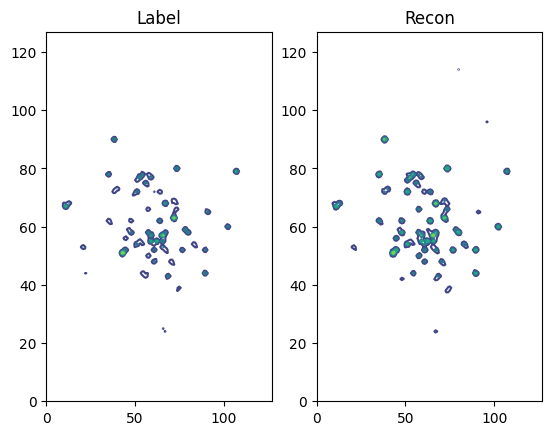

In [2]:
import nmrglue as ng
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as scio


def compute_rlne(x_true, x_pred):
    x_pred = np.array(x_pred)
    x_true = np.array(x_true)
    l2_error = np.linalg.norm(x_pred - x_true, ord=2)
    l2_true = np.linalg.norm(x_true, ord=2)
    rlne = l2_error / l2_true
    return rlne


def projection_3d(data, projection_type='skyline', iz1=1, izn=512, recon=False):
    '''
    Perform projection of 3D data along the third dimension.
    '''
    if projection_type == 'skyline':
        out = np.max(data[:, iz1 - 1:izn - 1, :], 1) / np.max(np.max(data[:, iz1 - 1:izn - 1, :], 1))
        # out = np.max(data[:, peak_position, :], 1) / np.max(np.max(data[:, peak_position, :], 1))
        # if not recon:
        #     out = np.max(data[:, iz1 - 1:izn - 1, :], 1) / np.max(np.max(data[:, iz1 - 1:izn - 1, :], 1))
        # else:
        #     out = np.max(data[:, peak_position, :], 1) / np.max(np.max(data[:, peak_position, :], 1))

        return out

    elif projection_type == 'sum':
        out = np.abs(np.sum(data[:, :, iz1 - 1:izn - 1], 2))
        return out

def iz1_izn(data_type):
    if data_type == 'PSRP':
        N1 = 32
        N2 = 32
        iz1 = 80
        izn = 180
        ppm1 = np.linspace(103.97273003, 133.59290332, N1)  # N15 32
        ppm2 = np.linspace(168.243315, 185.48343621, N2)  # CO  32

    elif data_type == 'A3DK08':
        N1 = 64
        N2 = 40
        iz1 = 70
        izn = 180
        ppm1 = np.linspace(164.54, 189.07, N1)  # C13  64
        ppm2 = np.linspace(101.83, 134.74, N2)  # N15  40


    elif data_type == 'specCnoesy':
        N1 = 150
        N2 = 64
        iz1 = 190
        izn = 370
        ppm1 = np.linspace(-2.69277800, 12.3113880, N1);  # 1H   150
        ppm2 = np.linspace(71.67634631, 9.71591854, N2);  # 13C  64

    elif data_type == 'mousethia':
        N1 = 55
        N2 = 40
        iz1 = 290
        izn = 330
        ppm1 = np.linspace(15.552939, 75.25997947, N1)  # CACB 55
        ppm2 = np.linspace(101.26288858, 135.83123601, N2)  # N15  40

    elif data_type == 'Ecolinird':
        N1 = 60
        N2 = 36
        iz1 = 100
        izn = 200
        ppm1 = np.linspace(11.64680295, 81.64694662, N1)  # CACB  60
        ppm2 = np.linspace(99.03853462, 134.62348861, N2)  # N15   36


    elif data_type == 'Altg':
        N1 = 64
        N2 = 128
        iz1 = 120
        izn = 210
        ppm1 = np.linspace(167.62, 187.64, N1)  # C13  32
        ppm2 = np.linspace(104.26, 133.89, N2)  # N15  40

    elif data_type == 'Yorp':
        N1 = 32
        N2 = 50
        iz1 = 140
        izn = 190
        ppm1 = np.linspace(12.46400863, 82.46398819, N1)  # CACB  34
        ppm2 = np.linspace(106.81524902, 130.81472222, N2)  # N15  34

    elif data_type == 'Yfgj':
        N1 = 34
        N2 = 34
        iz1 = 130
        izn = 220
        ppm1 = np.linspace(41.25573204, 71.25703962, N1)  # C13  34
        ppm2 = np.linspace(103.7399968, 132.74115, N2)  # N15  34

    elif data_type == 'Ykvr':
        N1 = 40
        N2 = 45
        iz1 = 100
        izn = 140
        ppm1 = np.linspace(102.04888518, 134.9338859, N1)  # N15  40
        ppm2 = np.linspace(-1.82879304, 11.52294876, N2)  # HN  45

    elif data_type == 'hncacb_6240' or data_type == 'hncacb_6240_1':
        N1 = 32
        N2 = 64
        # iz1 = 150
        # izn = 440
        iz1 = 100
        izn = 440

    return iz1, izn


if __name__ == '__main__':
    data_type = 'A3DK08'  # 'Altg' 'A3DK08' 'mousethia' 'Ecolinird' 'PSRP' 'hncacb_6240'  'Yfgj'
    model_type = 'Res-Conformer'  # Res-Conformer Dense-CNN JTF-Net  SMILE
    sample_rates = [15]  # 8, 10, 15, 20, 25 | 5,10,15,20,25,30,40,50,60,70,80,90
    iz1, izn = iz1_izn(data_type)
    # if data_type == 'mousethia' or data_type == 'Ecolinird':
    #     dic, data_label = ng.pipe.read(f"F:/NMRPipe/ReadNMRData/{data_type}/{data_type}_abs_3D_pad.ft")
    # else:
    #     # dic, data_label = ng.pipe.read(f"F:/NMRPipe/ReadNMRData/{data_type}/{data_type}_3D_pad_tmp.ft")

    dic, data_label = ng.pipe.read(f'./data/{data_type}_label.ft')
    dic, data_recon = ng.pipe.read(f'./data/{data_type}_recon.ft')
    # if data_type in['Ecolinird','mousethia']:
    #     data_label = np.abs(data_label)

    if data_type == 'hncacb_6240' or data_type == 'hncacb_6240_1':
        data_label = np.abs(data_label.transpose(1, 0, 2))
    data_label1 = data_label
    print(data_label.shape)
    data_label = np.fft.fftshift(data_label)
    data_label = projection_3d(data_label, projection_type='skyline', iz1=iz1, izn=izn)
    # data_label = np.fft.fftshift(data_label)

    data_recon = np.fft.fftshift(data_recon)
    data_recon = projection_3d(data_recon, projection_type='skyline', iz1=iz1, izn=izn,recon=False)
    # data_recon = np.fft.fftshift(data_recon)

    print(data_label.shape)
    plt.figure()
    level = 5
    plt.subplot(1, 2, 1)
    plt.contour(data_label, cmap='viridis', levels=level)
    plt.title('Label')
    plt.subplot(1, 2, 2)
    plt.contour(data_recon, cmap='viridis', levels=level)
    plt.title('Recon')
    plt.show()

    label_spec = data_label
    recon_spec = data_recon
    scio.savemat('./data/label_spec_3D.mat', {'label_spec': label_spec})
    scio.savemat('./data/recon_spec_3D.mat', {'recon_spec': recon_spec})